<a href="https://colab.research.google.com/github/YannC97/Yann-s-Coding-Projects/blob/Codes/RepAgent_Trans_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Solving the Rep. agent model with python and numba

## 1. Libraries

In [1434]:
pip install quantecon

In [1435]:
from numba import njit # library for JIT compilation
import numba
from matplotlib import pyplot as plt  # library for plotting
import numpy as np # standard library for linear algebra and math, works together with numba
import quantecon as qe # econ library by Stachurski and Sargent, implements useful things like Rouwenhorst and Tauchen method
from scipy.optimize import root # non-linear equation solver
from scipy.interpolate import splrep, splev # for splines

## 2. Utilities

### 2.1 A class for interpolating 1d data with splines
Now I define class to take care of the function approximation. This way will make it simpler to switch between approximation methods.
Each approximator, regardless which, will be initialized with pairs of (x,y) data (`Xdata` and `Ydata`) and it will have a `predict(x)` method to predict the output for input x. I use `scipy`'s interpolation. For cubic interpolation, an aditional parameter (next to the data) is `k`, the degree of the interpolating spline (`k=1` corresponds to linear interpolation and `k = 3` to cubic splines (see [Judd, Kubler and Schmedders (2000)](https://www.sciencedirect.com/science/article/abs/pii/S0165188999000366) for more on cubic splines in economics)).

In [1436]:
class spline_1d:
    def __init__(self, Xdata, Ydata, k = 1):
        # read out the shapes
        inputshape = Xdata.shape
        outputshape = Ydata.shape

        # check that the shapes are correct
        num_inp_points = inputshape[0]
        num_outp_points = outputshape[0]

        assert np.array_equal(inputshape, (num_inp_points, )), 'input should be of shape (?, )'
        assert np.array_equal(outputshape, (num_outp_points, )), 'output should be of shape (?, )'
        assert num_inp_points == num_outp_points, 'need equally many input and output points'

        # assert Xdata is nondecreasing (required)
        assert not(np.any(np.diff(Xdata) < 0)), 'Xdata has to be increasing'

        # store the data
        self.Xdata = Xdata.copy()
        self.Ydata = Ydata.copy()

        # store the degree of approximation
        self.k = k

        # create the spline
        self.spline = splrep(self.Xdata, self.Ydata, k = self.k)



    # define the predict method
    def predict(self, newdata):
        return splev(newdata, self.spline)

In [1437]:
Xdata = np.linspace(-1, 1, 6)
Ydata = Xdata ** 4

Xdata_test = np.linspace(-1.5, 1.5, 100)
Ydata_test = Xdata_test ** 4

# fit a piecewise linear and a cubic spline
pwlin_approximator = spline_1d(Xdata, Ydata, k = 1)
cubic_approximator = spline_1d(Xdata, Ydata, k = 3)

pred_test_pwlin = pwlin_approximator.predict(Xdata_test)
pred_test_cubic = cubic_approximator.predict(Xdata_test)

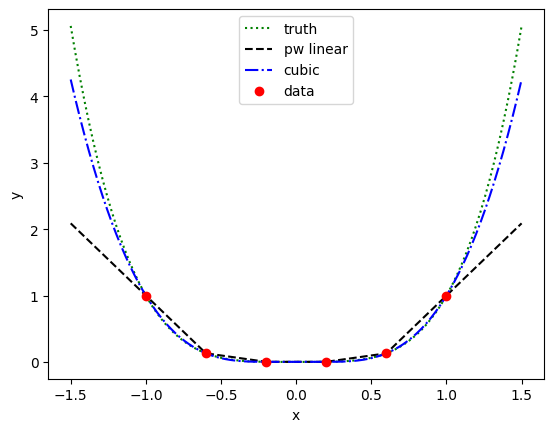

In [1438]:
plt.plot(Xdata_test, Ydata_test, 'g:', label = 'truth')
plt.plot(Xdata_test, pred_test_pwlin, 'k--', label = 'pw linear')
plt.plot(Xdata_test, pred_test_cubic, 'b-.', label = 'cubic')
plt.plot(Xdata, Ydata, 'ro', label = 'data')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


As we can see, the function inter- and extrapolates as we expect.

### 3.1 Parameters
#### 3.1.1 Economic parameters
We set the economic parameters as global variables.

In [1439]:
# Agents (CRRA TSEU. transitorz shocks, markov chain. cobb douglas production with 0.33 capital share)
gamma = 6.5 # risk aversion
beta = 0.835 # patience

# Production technology
alpha = 0.33 # Capital shate in production
L = 35 #aggregate labor -> 1.5?
delta= 0.26 # depreciation of capital 0.1
adj_xi = 0.05 # adjustment costs 10.

#### 3.1.2 Grid parameters

In [1440]:
# aggregate shocks (since this is the rep. agent model, only shocks for z)
z_vec = np.array([0.9415677131331878, 1.0, 1.0620585073721052]) # growth values
z_mean = np.mean(z_vec)
nZ = z_vec.shape[0] # number aggregate shocks
pi_Z = np.array([[0.8231025625, 0.168294875, 0.008602562499999999],
                 [0.0841474375, 0.8317051249999999, 0.0841474375],
                 [0.008602562499999999, 0.168294875, 0.8231025625]]) # transition matrix for aggregare shocks

# get steady level of capital (normalized, to guide our choice for the grid)
Kss = ((1. / (beta * z_mean ** (-gamma)) - 1. + delta) / alpha) ** (1. / (alpha - 1.)) * L
print(Kss)
# grid for normalized capital
nK = 200
Klow = 0.3 * Kss # lower bound  # 0.25
Khigh = 1.6 * Kss # upper bound
Kgrid = np.linspace(Klow, Khigh, nK) # grid for normalized capital

degree = 3 # degree for interpolation

20.841352851134094


### 3.2 Economic functions

In [1441]:
# marginal utility with shifter (first deriv CRRA, gamma is risk aversion param, as gamma -> max, as c incr, marginal util decr more steep)
def marg_u(c):
    return c ** (- gamma)

# normalized wage (wage is the marginal product of labor. diff. production function with respect to labor, dy/dL, add unit of labor -> output)
def wage(z, K):
    w = z * (1. - alpha) * L ** (- alpha) * K ** alpha
    return w

# normalized production (just prod.func cobb-douglas, note Z)
def prod(z, K):
    return z * K ** alpha * L ** (1. - alpha)

# marginal productivity of capital (marginal, prod. of capital. MPK, how much does 1 extra unit of capital gen output)
def marg_prod(z, K):
    return z * alpha * K ** (alpha - 1.) * L ** (1. - alpha)

def adjcost(Knext, K): #(penalize large changes, adj_xi controls magnitud of costs that are prop to K.)
    return adj_xi * K * (Knext / K - 1) ** 2

def marg_adjcost_1(Knext, K): #(first deriv, how the adjustment cost increases for a marginal increase in the capital adjustment ratio.)
    return 2 * adj_xi * (Knext / K - 1)

def marg_adjcost_2(Knext, K): #(what exactly and how is this computed?)
    return adj_xi * ((Knext / K) ** 2 - (1) ** 2)


### 3.3 Policy time iteration


#### 3.3.1 Euler equation

In [1442]:
# we start out by defining the Euler equation, which we will then solve at every gridpoint
def euler_error(Knext, zidx, K, approx_array): #Knext, capital next period. zidx = index period exog.shock, K=current period capital, approx-array= approx to get next period capital
    z = z_vec[zidx]

    adjc = adjcost(Knext, K) #adj costs
    m_adjc_1 = marg_adjcost_1(Knext, K) #marginal costs
    Y = prod(z, K) #production function, input techn and kapital
    C = Y + (1. - delta) * K - Knext - adjc #Consumption is given by output plus undepreciated capital minus investment in next period’s capital (Knext) and the adjustment cost.

    # get next periods variables
    Knextpr = np.empty(nZ)
    Ypr = np.empty(nZ)
    marg_prodpr = np.empty(nZ)
    Cpr = np.empty(nZ)
    adjcpr = np.empty(nZ)
    m_adjc_2pr = np.empty(nZ)
    prices = np.empty(nZ)

    for znidx in range(nZ): #what is the range hre? 3 shocks?
        zn = z_vec[znidx]
        Ypr[znidx] = prod(zn, Knext) #Next period production
        marg_prodpr[znidx] = marg_prod(zn, Knext) #NExt period capital


        # use approximation to predict next periods savings, spline method
        Knextpr[znidx] = approx_array[znidx].predict(np.array([Knext]))[0]

        # approx next periods adjustment costs-
        adjcpr[znidx] = adjcost(Knextpr[znidx], Knext)

        #next periods 2nd deriv of marg_adj costs.
        m_adjc_2pr[znidx] = marg_adjcost_2(Knextpr[znidx], Knext)

        #Next period consumption C_t+1. and prices = SDF, BETA*pi_s*ratio marginal utils (c_t+1 and C)
        Cpr[znidx] = Ypr[znidx] + (1. - delta) * Knext - Knextpr[znidx] - adjcpr[znidx]
        prices[znidx] = (beta * pi_Z[zidx, znidx] * marg_u(Cpr[znidx])) / marg_u(C)


    # get "return", effective return on capital.
    quasi_return = (marg_prodpr + 1. - delta + m_adjc_2pr) / (1. + m_adjc_1)

    #RHS of EULER, Note LHS normalized to 1, in eq. current marginal val of cap = discounted future exp.ret
    RHS = np.sum(prices * quasi_return)
    LHS = 1.
    # relative error in euler equation. recall LHS-RHS should be close to 0?
    res = (LHS - RHS) / LHS

    return res, C, prices

In [1443]:
K = Kss #Initial kapital is steady state Kapital
Y = prod(1, K) #Steady state production with techn = 1
zidx = 0 #shock index is first one
Knext = Kss #Next period
print(Kss)
# to initialize the approximator
Knext_approx_old = np.empty(nZ, dtype = object)
for zidx in range(nZ):
    Knext_approx_old[zidx] = spline_1d(Kgrid, 0.99 * Kgrid, k = degree)

20.841352851134094


In [1444]:
euler_error(3.6, zidx, K, Knext_approx_old) #zidx = 0, #K=steady state kapital #aproximation of knext_approx_old

(np.float64(-1014.5963874329977),
 np.float64(42.43649725611386),
 array([  7.1964273 ,  93.00049006, 300.89659026]))

#### 3.3.2 One iteration step

In [1445]:
def iteration(z_vec, Kgrid, Knext_approx_old):
    nZ = z_vec.shape[0] #number of shock state
    nK = Kgrid.shape[0] #number of grid points

    # we construct an empty array to save the new investment ratios
    Knext_new = np.empty((nZ, nK))

    # loop through aggregate shocks
    for zidx in range(nZ):
        # loop through K-gridpoints
        for kidx in range(nK):
            # read out K and Y
            K = Kgrid[kidx]

            # define the function to solve (only the Euler residual is returned), minimize the errors.
            def to_solve(Knext):
                res, C, prices = euler_error(Knext, zidx, K, Knext_approx_old)
                return res

            # get a starting guess
            Knext_start = Knext_approx_old[zidx].predict(K)

            # solve the Euler equation, root of a vector function, with Knext_start
            sol = root(to_solve, Knext_start)

            # assert solved correctly
            assert np.abs(to_solve(sol.x)) < 1e-4, 'not well solved'

            # save the solution
            Knext_new[zidx, kidx] = sol.x

    return Knext_new

In [1446]:
Knext_new = iteration(z_vec, Kgrid, Knext_approx_old)

<ipython-input-1442-4ec545c8098f>:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Ypr[znidx] = prod(zn, Knext) #Next period production
<ipython-input-1442-4ec545c8098f>:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  marg_prodpr[znidx] = marg_prod(zn, Knext) #NExt period capital
<ipython-input-1442-4ec545c8098f>:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Knextpr[znidx] = approx_array[znidx].predict(np.array([Knext]))[0]
<ipython-input-1442-4ec545c8098f>:

#### 3.3.3 Update the approximator

In [1447]:
# to fit nZ functions with nK gridpoints.
def get_approximator_nZnK(Kgrid, vec_new, degree = 1):
    # check dimensions
    nK = Kgrid.shape[0]
    nZ = vec_new.shape[0]
    assert vec_new.shape[1] == nK, 'vec_new should be of shape ({}, {})'.format(nZ, nK)

    new_approx = np.empty(nZ, dtype = object)

    for zidx in range(nZ):
        current_Knext_new = vec_new[zidx, :]

        new_approx[zidx] = spline_1d(Kgrid,current_Knext_new, k = degree)

    return new_approx

# to fit nZ x nZ functions with nK gridpoints
def get_approximator_nZnKnZ(Kgrid, vec_new, degree = 1):
    # check dimensions
    nK = Kgrid.shape[0]
    nZ = Knext_new.shape[0]

    #check dimensions
    assert vec_new.shape[1] == nK, 'vec_new should be of shape ({}, {}, {})'.format(nZ, nK, nZ)
    assert vec_new.shape[2] == nZ, 'vec_new should be of shape ({}, {}, {})'.format(nZ, nK, nZ)

    new_approx = np.empty((nZ, nZ), dtype = object)

    for zidx in range(nZ):
        for znidx in range(nZ):
            current_Knext_new = vec_new[zidx, :, znidx]

            new_approx[zidx, znidx] = spline_1d(Kgrid, current_Knext_new, k = degree)

    return new_approx


In [1448]:
Knext_approx_new = get_approximator_nZnK(Kgrid, Knext_new, degree = degree)

#### 3.3.4 Putting it all together

In [1449]:
def converge_rep_agent(z_vec, Kgrid, thresh = 1e-6, maxiter = 1000, degree = 1, print_interval = 10):
    nK = Kgrid.shape[0] #number of grids
    nZ = z_vec.shape[0] #number of schock

    # initialize the investment values (K_next old will have k_grid, the gridpoints for each shock.)
    Knext_old = np.empty((nZ, nK))
    for zidx in range(nZ):
        Knext_old[zidx, :] = Kgrid

    # initialize the approximator (call the spline.)
    Knext_approx_old = np.empty(nZ, dtype = object)
    for zidx in range(nZ):
        Knext_approx_old[zidx] = spline_1d(Kgrid, Knext_old[zidx, :], k = degree)

    # initalize the difference and success
    dif = 10000.
    success = False

    for i in range(maxiter):
        # compute the new Knext policy
        Knext_new = iteration(z_vec, Kgrid, Knext_approx_old)

        # get the new approximator
        Knext_approx_new = get_approximator_nZnK(Kgrid, Knext_new, degree = degree)

        # compute the difference between new and old
        dif = np.max(np.abs(Knext_new - Knext_old))

        # update the old
        Knext_old = Knext_new


        Knext_approx_old = Knext_approx_new

        # check if convergence criterion is reached
        if dif < thresh:
            success = True
            print('Policy time iteration converged after {} iterations with maximum difference [log10] = {:.2f}'.format(i, np.log10(dif)))
            # get pices and consumption

            return Knext_approx_new, Knext_new, success

        # print progress
        if i % print_interval == 0:
            print('Policy time iteration {}, maximum difference [log10] = {:.2f}'.format(i, np.log10(dif)))

    # if this point is reached, the algorithm did not converge
    print('Not converged after {} iterations!!! Maximum difference [log10] = {:.2f}'.format(i, np.log10(dif)))
    return Knext_approx_new, Knext_new, success



In [1450]:
Knext_approx_new, Knext_new, success = converge_rep_agent(z_vec, Kgrid, degree = degree)

<ipython-input-1442-4ec545c8098f>:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Ypr[znidx] = prod(zn, Knext) #Next period production
<ipython-input-1442-4ec545c8098f>:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  marg_prodpr[znidx] = marg_prod(zn, Knext) #NExt period capital
<ipython-input-1442-4ec545c8098f>:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Knextpr[znidx] = approx_array[znidx].predict(np.array([Knext]))[0]
<ipython-input-1442-4ec545c8098f>:

Policy time iteration 0, maximum difference [log10] = -0.12
Policy time iteration 10, maximum difference [log10] = -1.59
Policy time iteration 20, maximum difference [log10] = -3.20
Policy time iteration 30, maximum difference [log10] = -4.80
Policy time iteration converged after 38 iterations with maximum difference [log10] = -6.00


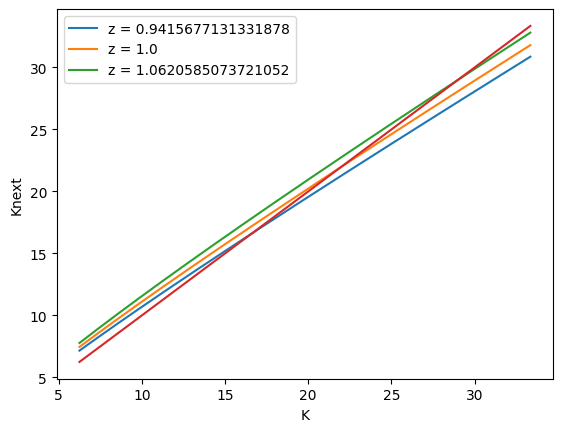

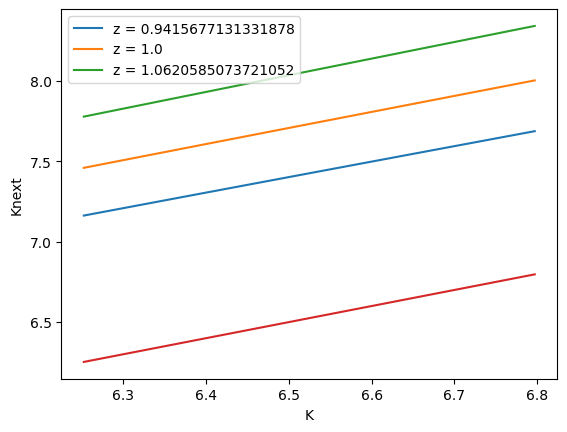

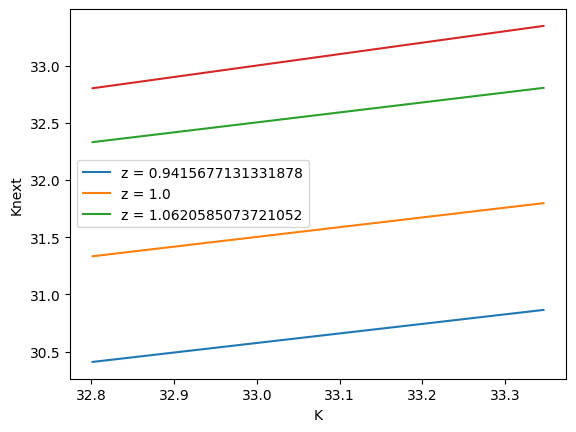

In [1451]:
for zidx in range(nZ):
  plt.plot(Kgrid, Knext_new[zidx, :], label = 'z = {}'.format(z_vec[zidx]))
plt.plot(Kgrid, Kgrid)
plt.xlabel(r'K')
plt.ylabel(r'Knext')
plt.legend()
plt.show()

for zidx in range(nZ):
    plt.plot(Kgrid[0 : 5], Knext_new[zidx, 0 :5], label = 'z = {}'.format(z_vec[zidx]))
plt.plot(Kgrid[0 : 5], Kgrid[0 : 5])
plt.xlabel(r'K')
plt.ylabel(r'Knext')
plt.legend()
plt.show()


for zidx in range(nZ):
    plt.plot(Kgrid[-5:], Knext_new[zidx, -5:], label = 'z = {}'.format(z_vec[zidx]))
plt.plot(Kgrid[-5:], Kgrid[-5:])
plt.xlabel(r'K')
plt.ylabel(r'Knext')
plt.legend()
plt.show()

## 4. Firm value and dividends

For the simulation we are also interested in the prices, firm value and the dividends. First we compute the prices and the quantities we can get without iterating.

In [1452]:
def get_quantities(z_vec, Kgrid, Knext_approx):
    nZ = z_vec.shape[0]
    nK = Kgrid.shape[0]

    # we construct an empty array to save prices and consumption
    prices_new = np.empty((nZ, nK, nZ))
    C_new = np.empty((nZ, nK))
    I_new = np.empty((nZ, nK))
    div_new = np.empty((nZ, nK))
    adjc_new = np.empty((nZ, nK))
    Knext_new = np.empty((nZ, nK))

    # loop through aggregate shocks
    for zidx in range(nZ):
        z = z_vec[zidx]

        # loop through K-gridpoints
        for kidx in range(nK):
            # read out K and Y
            K = Kgrid[kidx]

            Y = prod(z, K)

            # get wage
            w = wage(z, K)

            # get Knext from approximation
            Knext = Knext_approx[zidx].predict(K)

            # get
            I = Knext - (1 - delta) * K

            # get adjustment costs
            adjc = adjcost(Knext, K)

            # get dividends
            div = Y - w * L - I - adjc

            # get Euler error, consumption and prices
            res, C, prices = euler_error(Knext, zidx, K, Knext_approx)

            # assert the Euler error is small
            assert np.max(np.abs(res)) < 1e-4, 'this policy doesnt solve the Euler equation'

            # save consumption and prices
            C_new[zidx, kidx] = C
            prices_new[zidx, kidx, :] = prices
            I_new[zidx, kidx] = I
            div_new[zidx, kidx] = div
            adjc_new[zidx, kidx] = adjc
            Knext_new[zidx, kidx] = Knext

    return C_new, prices_new, I_new, div_new, adjc_new, Knext_new

In [1453]:
 C_new, prices_new, I_new, div_new, adjc_new, Knext_new = get_quantities(z_vec, Kgrid, Knext_approx_new)

In [1454]:
Kgrid

array([ 6.25240586,  6.3885554 ,  6.52470494,  6.66085448,  6.79700402,
        6.93315356,  7.0693031 ,  7.20545264,  7.34160219,  7.47775173,
        7.61390127,  7.75005081,  7.88620035,  8.02234989,  8.15849943,
        8.29464897,  8.43079852,  8.56694806,  8.7030976 ,  8.83924714,
        8.97539668,  9.11154622,  9.24769576,  9.3838453 ,  9.51999485,
        9.65614439,  9.79229393,  9.92844347, 10.06459301, 10.20074255,
       10.33689209, 10.47304163, 10.60919117, 10.74534072, 10.88149026,
       11.0176398 , 11.15378934, 11.28993888, 11.42608842, 11.56223796,
       11.6983875 , 11.83453705, 11.97068659, 12.10683613, 12.24298567,
       12.37913521, 12.51528475, 12.65143429, 12.78758383, 12.92373338,
       13.05988292, 13.19603246, 13.332182  , 13.46833154, 13.60448108,
       13.74063062, 13.87678016, 14.01292971, 14.14907925, 14.28522879,
       14.42137833, 14.55752787, 14.69367741, 14.82982695, 14.96597649,
       15.10212604, 15.23827558, 15.37442512, 15.51057466, 15.64

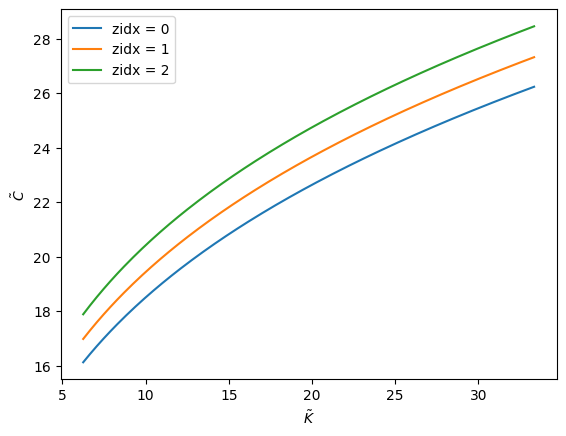

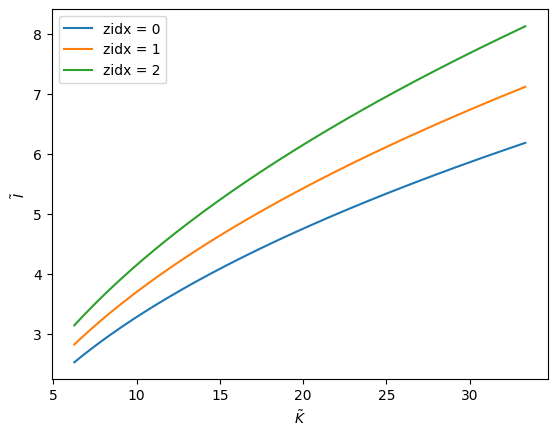

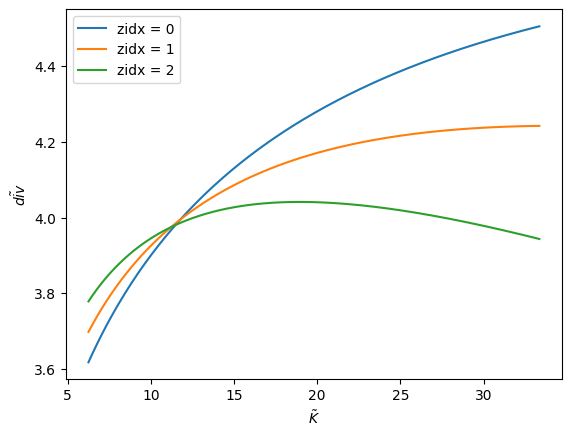

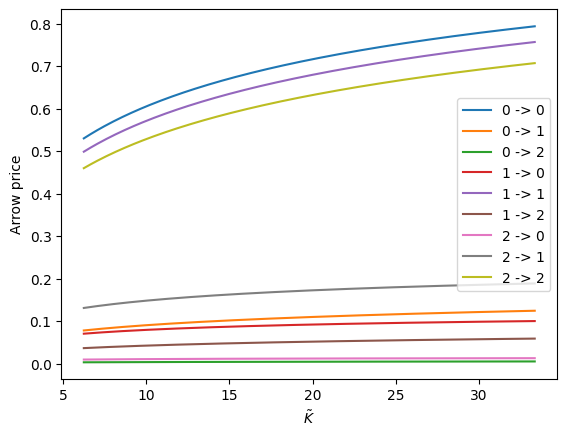

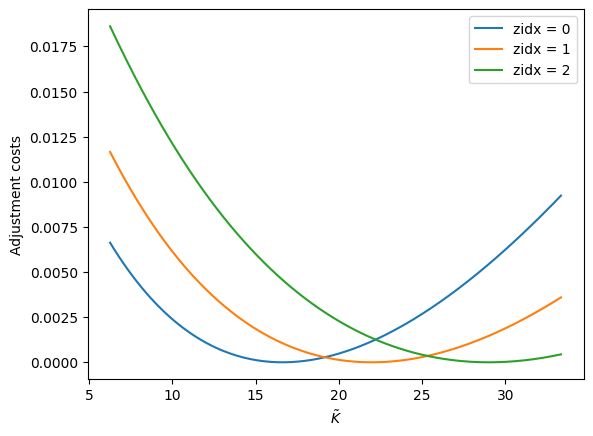

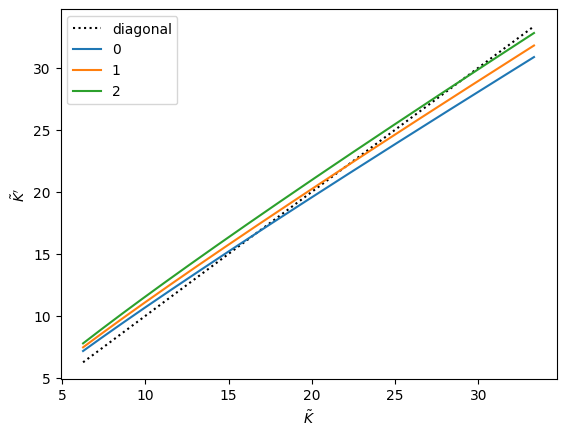

In [1455]:
# plot these quantities
# consumption
for zidx in range(nZ):
    plt.plot(Kgrid, C_new[zidx, :], label = 'zidx = {}'.format(zidx))
plt.xlabel(r'$\tilde{K}$')
plt.ylabel(r'$\tilde{C}$')
plt.legend()
plt.show()

# investment
for zidx in range(nZ):
    plt.plot(Kgrid, I_new[zidx, :], label = 'zidx = {}'.format(zidx))
plt.xlabel(r'$\tilde{K}$')
plt.ylabel(r'$\tilde{I}$')
plt.legend()
plt.show()

# dividends
for zidx in range(nZ):
    plt.plot(Kgrid, div_new[zidx, :], label = 'zidx = {}'.format(zidx))
plt.xlabel(r'$\tilde{K}$')
plt.ylabel(r'$\tilde{div}$')
plt.legend()
plt.show()

# prices
for zidx in range(nZ):
    for znidx in range(nZ):
        plt.plot(Kgrid, prices_new[zidx, :, znidx], label = '{} -> {}'.format(zidx, znidx))
plt.xlabel(r'$\tilde{K}$')
plt.ylabel('Arrow price')
plt.legend()
plt.show()

# adjc
for zidx in range(nZ):
    plt.plot(Kgrid, adjc_new[zidx, :], label = 'zidx = {}'.format(zidx))
plt.xlabel(r'$\tilde{K}$')
plt.ylabel('Adjustment costs')
plt.legend()
plt.show()

# Knext
plt.plot(Kgrid, Kgrid, 'k:', label = 'diagonal')
for zidx in range(nZ):
    plt.plot(Kgrid, Knext_new[zidx, :], label = '{}'.format(zidx))
plt.xlabel(r'$\tilde{K}$')
plt.ylabel(r'$\tilde{K}^\prime$')
plt.legend()
plt.show()

In [1456]:
# get interpolations for the dividends, consumption and prices
div_approx = get_approximator_nZnK(Kgrid, div_new, degree = degree)
C_approx = get_approximator_nZnK(Kgrid, C_new, degree = degree)
prices_approx = get_approximator_nZnKnZ(Kgrid, prices_new, degree = degree)
Knext_approx = get_approximator_nZnK(Kgrid, Knext_new, degree = degree)

In [1457]:
# 1. a single iteration
def iterate_Vfirm(z_vec, Kgrid, prices_new, div_new, Knext_new, Vfirm_approx):
    nZ = z_vec.shape[0]
    nK = Kgrid.shape[0]

    Vfirm_new = np.empty((nZ, nK))

    # iterate through gridpoints
    for zidx in range(nZ):
        for kidx in range(nK):
            # get dividends
            div = div_new[zidx, kidx]

            # get prices
            prices = prices_new[zidx, kidx, :]

            # get Knext
            Knext = Knext_new[zidx, kidx]

            # get firm value in the next period using the approximator
            Vfirmnext_vec = np.empty(nZ)
            for znidx in range(nZ):
                Vfirmnext_vec[znidx] = Vfirm_approx[znidx].predict(Knext)

            # compute new firm value
            Vfirm_new[zidx, kidx] = div + np.sum(prices * Vfirmnext_vec)

    return Vfirm_new


In [1458]:
# 3. iterate to convergence
def converge_Vfirm(z_vec, Kgrid, prices_new, div_new, Knext_new, thresh = 1e-6, maxiter = 1000, degree = 1, print_interval = 10):
    nK = Kgrid.shape[0]
    nZ = z_vec.shape[0]

    # initialize the Vfirm values, we assume start out with dividends (then iteration i would be the solution in an i-period model)
    Vfirm_old = div_new.copy()

    # initialize the approximator
    Vfirm_approx_old = np.empty(nZ, dtype = object)
    for zidx in range(nZ):
        Vfirm_approx_old[zidx] = spline_1d(Kgrid, Vfirm_old[zidx, :], k = degree)

    # initalize the difference and success
    dif = 10000.
    success = False

    for i in range(maxiter):
        # compute the new firm value
        Vfirm_new = iterate_Vfirm(z_vec, Kgrid, prices_new, div_new, Knext_new, Vfirm_approx_old)

        # get the new approximator
        Vfirm_approx_new = get_approximator_nZnK(Kgrid, Vfirm_new, degree = degree)

        # compute the difference between new and old
        dif = np.max(np.abs(Vfirm_new - Vfirm_old))

        # update the old
        Vfirm_old = Vfirm_new
        Vfirm_approx_old = Vfirm_approx_new

        # check if convergence criterion is reached
        if dif < thresh:
            success = True
            print('Firm value converged after {} iterations with maximum difference [log10] = {:.2f}'.format(i, np.log10(dif)))
            # get pices and consumption

            return Vfirm_approx_new, Vfirm_new, success

        # print progress
        if i % print_interval == 0:
            print('Iteration {}, maximum difference [log10] = {:.2f}'.format(i, np.log10(dif)))

    # if this point is reached, the algorithm did not converge
    print('Firm value not converged after {} iterations!!! Maximum difference [log10] = {:.2f}'.format(i, np.log10(dif)))
    return Vfirm_approx_new, Vfirm_new, success


In [1459]:
Vfirm_approx_new, Vfirm_new, success = converge_Vfirm(z_vec, Kgrid, prices_new, div_new, Knext_new)

Iteration 0, maximum difference [log10] = 0.61
Iteration 10, maximum difference [log10] = 0.08
Iteration 20, maximum difference [log10] = -0.59
Iteration 30, maximum difference [log10] = -1.34
Iteration 40, maximum difference [log10] = -2.12
Iteration 50, maximum difference [log10] = -2.90
Iteration 60, maximum difference [log10] = -3.68
Iteration 70, maximum difference [log10] = -4.46
Iteration 80, maximum difference [log10] = -5.25
Firm value converged after 90 iterations with maximum difference [log10] = -6.03


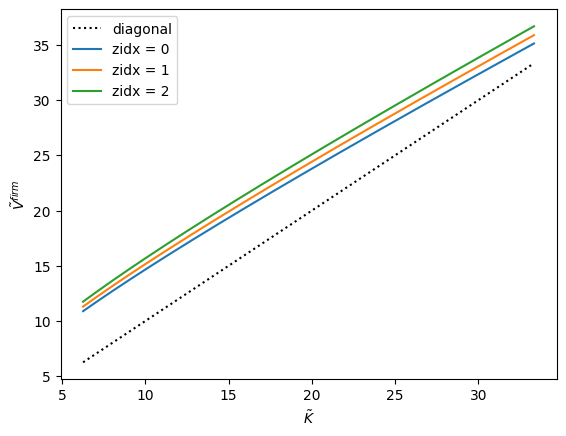

In [1460]:
plt.plot(Kgrid, Kgrid, 'k:', label = 'diagonal')
for zidx in range(nZ):
    plt.plot(Kgrid, Vfirm_new[zidx, :], label = 'zidx = {}'.format(zidx))
plt.xlabel(r'$\tilde{K}$')
plt.ylabel(r'$\tilde{V}^{firm}$')
plt.legend()
plt.show()


## 5. Simulation
Now that we have our approximation of the functional rational expectations equilibrium computed (to be precise, maybe a more appropriate notion of what we really computed could be [Kubler and Scheidegger (2020)](https://drive.google.com/file/d/1N-m-w8xpnJqpWvxdy-o1r3tUaMGeGYBj/view) or [Geng (2019)](https://drive.google.com/file/d/1RJ0PxRb0mYSOeV8qzoYIWm31ziwodsPF/view)), we would like to use the policy function to simulate the economy.

In [1461]:
@njit  # speeds up the function with Numba
def sim_shocks(zidx_0, z_vec, T, trans_probs, rho_x, sigma_x, g_z):
    """
    Simulate a sequence of T exogenous shocks according to the given transition matrix,
    while incorporating long-run productivity risk as in Croce (2008).

    The technology level at time t is given by:
      z_evol[t] = (1 + g_z)^t * exp(x[t]) * z_vec[state],
    where the long-run component x evolves as:
      x[t+1] = rho_x * x[t] + sigma_x * N(0,1).

    Parameters:
      zidx_0    : initial index for the shock state (integer)
      z_vec     : numpy array of base shock values for each state
      T         : number of periods to simulate
      trans_probs: Markov transition matrix (shape (nZ, nZ))
      rho_x     : persistence parameter for the long-run productivity risk component (e.g., 0.98)
      sigma_x   : standard deviation of the long-run productivity risk shocks
      g_z       : deterministic trend growth rate (e.g., 0.02 for 2% per period)

    Returns:
      zidx_evol : numpy array (length T) of simulated shock state indices
      z_evol    : numpy array (length T) of simulated technology shock levels,
                  which incorporate both the deterministic trend and the long-run risk component.
      x_evol    : numpy array (length T) of the long-run risk component
    """
    nZ = z_vec.shape[0]

    zidx_evol = np.empty(T, numba.uint32)
    z_evol = np.empty(T, numba.double)
    x_evol = np.empty(T, numba.double)

    # Initialize: at t=0, set state and long-run component to base values.
    zidx_old = zidx_0
    zidx_evol[0] = zidx_0
    z_evol[0] = z_vec[zidx_0]
    x_evol[0] = 0.0  # start with no deviation in long-run risk

    # Draw random numbers for the Markov chain transitions.
    rands = np.random.rand(T)

    for t in range(1, T):
        # Update the long-run risk component: persistent AR(1) process.
        x_evol[t] = rho_x * x_evol[t-1] + sigma_x * np.random.normal()

        rand = rands[t]
        agg_trans = 0.0
        for znidx in range(nZ):
            agg_trans += trans_probs[zidx_old, znidx]
            if rand <= agg_trans or znidx == nZ - 1:
                zidx_evol[t] = znidx
                zidx_old = znidx
                # Compute the technology level by combining the deterministic trend and
                # the stochastic long-run component with the base shock value.
                z_evol[t] = ((1 + g_z) ** t) * np.exp(x_evol[t]) * z_vec[znidx]
                break

    return zidx_evol, z_evol

# Example usage:
# Suppose we have three shock states with base values in z_vec,
# a transition matrix trans_probs (each row sums to one), and we want to simulate T periods.




In [1462]:
zidx_0 = 0
T = 50
# Long-run risk parameters (example calibration):
rho_x = 1.0      # high persistence
sigma_x = 0.000   # volatility of long-run risk shocks (adjust to match your moments)
g_z = 0.02    # deterministic monthly growth rate corresponding to ~2% annual growth

zidx_evol, z_evol = sim_shocks(zidx_0, z_vec, T, pi_Z, rho_x, sigma_x, g_z)

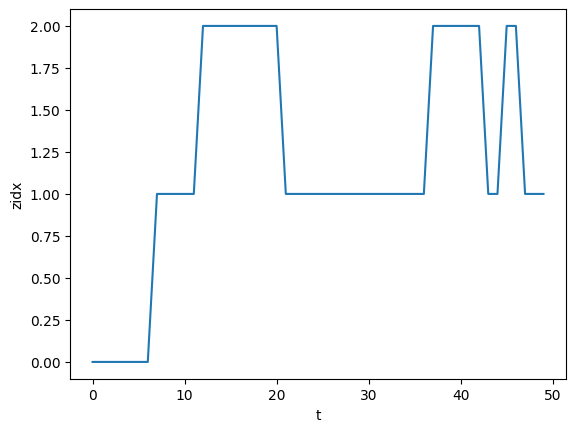

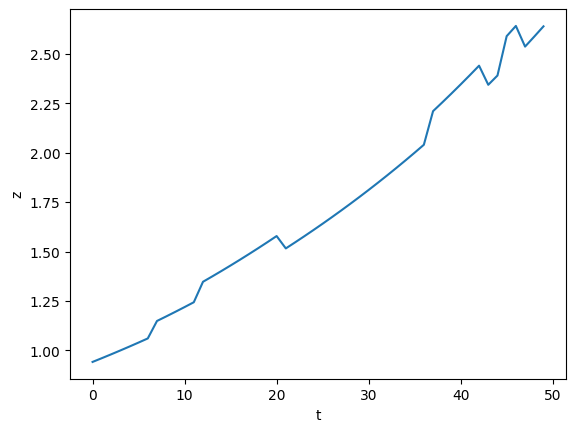

In [1463]:
plt.plot(zidx_evol)
plt.ylabel('zidx')
plt.xlabel('t')
plt.show()

plt.plot(z_evol)
plt.ylabel('z')
plt.xlabel('t')
plt.show()



Next we need a function which simulates all the remaining quantities we may be interested in.

In [1464]:
def simulate(T, zidx_0, K_0, z_vec, pi_Z, Knext_approx, Vfirm_approx, prices_approx, rho_x, sigma_x, g_z):
    nZ = z_vec.shape[0]

    # get the exogenous part
    zidx_evol, z_evol = sim_shocks(zidx_0, z_vec, T, pi_Z,rho_x, sigma_x, g_z)


    # initialize all the other arrays we want to keep track of
    K_evol = np.empty(T)
    I_evol = np.empty(T)
    C_evol = np.empty(T)
    Y_evol = np.empty(T)
    w_evol = np.empty(T)
    prices_evol = np.empty((T, nZ))
    Vfirm_evol = np.empty(T)
    Vfirmnext_evol = np.empty((T, nZ))
    bondret_evol = np.empty(T)
    stockret_evol = np.empty(T)
    equp_evol = np.empty(T)
    div_evol = np.empty(T)
    mpr_evol = np.empty(T)
    adjc_evol = np.empty(T)

    # initialize starting value of capital
    K_evol[0] = K_0

    # simulate the rest
    for t in range(T):
        zt = z_evol[t]
        zidxt = zidx_evol[t]
        Kt = K_evol[t]
        if t < T - 1:
            znidxt = zidx_evol[t + 1]

        # macro quantities
        Yt = prod(zt, Kt)
        Knext = Knext_approx[zidxt].predict(Kt)
        It = Knext - Kt * (1. - delta)
        wt = wage(zt, Kt)
        adjct = adjcost(Knext, Kt)
        divt = Yt - It - wt * L - adjct
        Ct = Yt - It - adjct

        # prices
        pricest = np.empty(nZ)
        for znidx in range(nZ):
            pricest[znidx] = prices_approx[zidxt, znidx].predict(Kt)

        # firm value
        Vfirmt = Vfirm_approx[zidxt].predict(Kt)

        if t < T - 1:
            K_evol[t+1] = Knext

        # get next periods firm value
        Vfirm_nextt = np.empty(nZ)
        for znidx in range(nZ):
            Vfirm_nextt[znidx] = Vfirm_approx[znidx].predict(Knext)

        # get returns
        # bond
        payout_bt = 1.
        price_bondt = np.sum(pricest)
        ret_bondt = payout_bt / price_bondt - 1.

        # equity
        stoch_payout_firmt = Vfirm_nextt
        exp_payout_firmt = np.sum(pi_Z[zidxt, :] * stoch_payout_firmt)
        price_firmt = np.sum(pricest * stoch_payout_firmt)
        ret_firmt = exp_payout_firmt / price_firmt - 1.

        # equity premium
        ret_equpt = ret_firmt - ret_bondt

        # market price of risk
        mpr_expt = price_bondt
        mpr_stdt = np.sum(pi_Z[zidxt, :] * (pricest / pi_Z[zidxt, :] - mpr_expt) ** 2.) ** 0.5
        mprt = mpr_stdt / mpr_expt

        # write everything inside the arrays
        I_evol[t] = It
        C_evol[t] = Ct
        Y_evol[t] = Yt
        w_evol[t] = wt
        adjc_evol[t] = adjct
        prices_evol[t] = pricest
        Vfirm_evol[t] = Vfirmt
        Vfirmnext_evol[t] = Vfirm_nextt
        bondret_evol[t] = ret_bondt
        stockret_evol[t] = ret_firmt
        equp_evol[t] = ret_equpt
        div_evol[t] = divt
        mpr_evol[t] = mprt

    # put everything into a dictionary to return
    sim_dict = {}
    sim_dict['zidx'] = zidx_evol
    sim_dict['z'] = z_evol
    sim_dict['K'] = K_evol
    sim_dict['I'] = I_evol
    sim_dict['C'] = C_evol
    sim_dict['Y'] = Y_evol
    sim_dict['w'] = w_evol
    sim_dict['prices'] = prices_evol
    sim_dict['Vfirm'] = Vfirm_evol
    sim_dict['Vfirmnext'] = Vfirmnext_evol
    sim_dict['bondret'] = bondret_evol
    sim_dict['stockret'] = stockret_evol
    sim_dict['equp'] = equp_evol
    sim_dict['div'] = div_evol
    sim_dict['mpr'] = mpr_evol
    sim_dict['adjc'] = adjc_evol

    return sim_dict

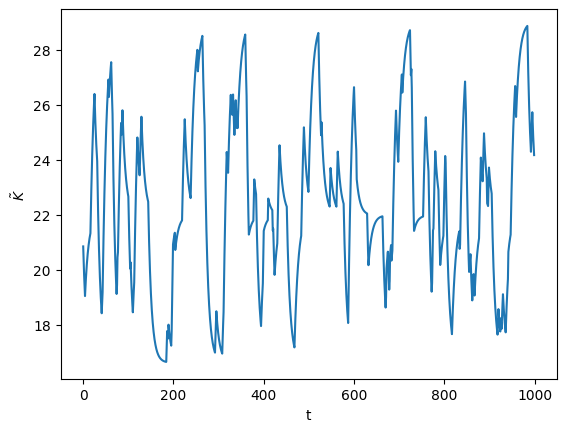

In [1465]:
T = 1000
zidx_0 =  0
K_0 = Kss

sim_dict = simulate(T, zidx_0, K_0, z_vec, pi_Z, Knext_approx_new, Vfirm_approx_new, prices_approx,rho_x, sigma_x, g_z)

plt.plot(sim_dict['K'])
plt.ylabel(r'$\tilde{K}$')
plt.xlabel('t')
plt.show()

For the plots and analysis, we make a separate function.

In [1466]:
def analysis(sim_dict):
    # compute mean statistics
    print('#' + '=' * 50)
    print('Mean:')
    for key in sim_dict:
        print('mean ' + key + ' = ', np.mean(sim_dict[key], axis = 0))

    # compute std statistics
    print('#' + '=' * 50)
    print('Std:')
    for key in sim_dict:
        print('std ' + key + ' = ', np.std(sim_dict[key], axis = 0))

    print('#' + '=' * 50)
    print('Mean by shock:')
    for key in sim_dict:
        for zidx in range(nZ):
            mask = (sim_dict['zidx'] == zidx)
            print('Shock ' + str(zidx) + ': mean ' + key + ' = ', np.mean(sim_dict[key][mask], axis = 0))



    # compute selected unnormalized variables
    Yreal = sim_dict['Y']
    Kreal = sim_dict['K']
    Ireal = sim_dict['I']
    Creal = sim_dict['C']
    Vfirmreal = sim_dict['Vfirm']
    wreal = sim_dict['w']
    divreal = sim_dict['div']



    # compute growth rates
    Ygrowth = Yreal[1:] / Yreal[:-1]
    Igrowth = Ireal[1:] / Ireal[:-1]
    Cgrowth = Creal[1:] / Creal[:-1]
    Kgrowth = Kreal[1:] / Kreal[:-1]
    Vfirmgrowth = Vfirmreal[1:] / Vfirmreal[:-1]
    wgrowth = wreal[1:] / wreal[:-1]
    divgrowth = divreal[1:] / divreal[:-1]

    # report growth statistics
    print('#' + '=' * 50)
    print('Growth:')
    print('Y: mean = {:.4f}, std = {:.4f}'.format(np.mean(Ygrowth), np.std(Ygrowth)))
    print('C: mean = {:.4f}, std = {:.4f}, std(C)/std(Y) = {:.4f}'.format(np.mean(Cgrowth), np.std(Cgrowth), np.std(Cgrowth) / np.std(Ygrowth)))
    print('I: mean = {:.4f}, std = {:.4f}, std(I)/std(Y) = {:.4f}'.format(np.mean(Igrowth), np.std(Igrowth), np.std(Igrowth) / np.std(Ygrowth)))
    print('K: mean = {:.4f}, std = {:.4f}, std(K)/std(Y) = {:.4f}'.format(np.mean(Kgrowth), np.std(Kgrowth), np.std(Kgrowth) / np.std(Ygrowth)))
    print('w: mean = {:.4f}, std = {:.4f}, std(w)/std(Y) = {:.4f}'.format(np.mean(wgrowth), np.std(wgrowth), np.std(wgrowth) / np.std(Ygrowth)))
    print('div: mean = {:.4f}, std = {:.4f}, std(div)/std(Y) = {:.4f}'.format(np.mean(divgrowth), np.std(divgrowth), np.std(divgrowth) / np.std(Ygrowth)))
    print('Vfirm: mean = {:.4f}, std = {:.4f}, std(Vfirm)/std(Y) = {:.4f}'.format(np.mean(Vfirmgrowth), np.std(Vfirmgrowth), np.std(Vfirmgrowth) / np.std(Ygrowth)))
    print('Vfirm: log V/E = {:.4f}'.format(np.log(np.mean(Vfirmgrowth)/np.mean(Ygrowth))))


    print('#' + '=' * 50)
    print('Correlations of growth with output growth:')
    print('C = {:.4f}'.format(np.corrcoef(Ygrowth, Cgrowth)[0, 1]))
    print('I = {:.4f}'.format(np.corrcoef(Ygrowth, Igrowth)[0, 1]))
    print('K = {:.4f}'.format(np.corrcoef(Ygrowth, Kgrowth)[0, 1]))
    print('w = {:.4f}'.format(np.corrcoef(Ygrowth, wgrowth)[0, 1]))
    print('div = {:.4f}'.format(np.corrcoef(Ygrowth, divgrowth)[0, 1]))
    print('Vfirm = {:.4f}'.format(np.corrcoef(Ygrowth, Vfirmgrowth)[0, 1]))

    print('#' + '=' * 50)
    print('Return correlations with unnormalized output:')
    print('Bond return (expected) = {:.4f}'.format(np.corrcoef(Yreal, sim_dict['bondret'])[0, 1]))
    print('Stock return (expected) = {:.4f}'.format(np.corrcoef(Yreal, sim_dict['stockret'])[0, 1]))
    print('Equity premium (expected) = {:.4f}'.format(np.corrcoef(Yreal, sim_dict['equp'])[0, 1]))
    print('mpr = {:.4f}'.format(np.corrcoef(Yreal, sim_dict['mpr'])[0, 1]))

    print('#' + '=' * 50)
    print('Return correlations with output growth:')
    print('Bond return (expected) = {:.4f}'.format(np.corrcoef(Ygrowth, sim_dict['bondret'][1:])[0, 1]))
    print('Stock return (expected) = {:.4f}'.format(np.corrcoef(Ygrowth, sim_dict['stockret'][1:])[0, 1]))
    print('Equity premium (expected) = {:.4f}'.format(np.corrcoef(Ygrowth, sim_dict['equp'][1:])[0, 1]))
    print('mpr = {:.4f}'.format(np.corrcoef(Ygrowth, sim_dict['mpr'][1:])[0, 1]))
    print('#' + '=' * 50)


    # now we make some plots
    plt.plot(np.log(Kreal), label = 'K')
    plt.plot(np.log(Yreal), label = 'Y')
    plt.plot(np.log(Creal), label = 'C')
    plt.plot(np.log(Ireal), label = 'I')
    plt.legend()
    plt.xlabel('t')
    plt.ylabel('[log]')
    plt.show()

    plt.plot(Kgrowth, label = 'K')
    plt.plot(Ygrowth, label = 'Y')
    plt.plot(Cgrowth, label = 'C')
    plt.plot(Igrowth, label = 'I')
    plt.legend()
    plt.xlabel('t')
    plt.ylabel('growth')
    plt.show()

    # interest rate, mpr and eqpu
    plt.plot(sim_dict['bondret'])
    plt.xlabel('t')
    plt.ylabel('interest rate')
    plt.show()

    plt.plot(sim_dict['mpr'])
    plt.xlabel('t')
    plt.ylabel('mpr')
    plt.show()

    plt.plot(sim_dict['equp'])
    plt.xlabel('t')
    plt.ylabel('equp')
    plt.show()

In [1467]:
pwd

'/content'

#==================================================
Mean:
mean zidx =  1.038
mean z =  20321990.1133348
mean K =  22.43035649314126
mean I =  5.834941993260698
mean C =  630639529.073445
mean Y =  630639534.9088093
mean w =  12072242.52539721
mean prices =  [0.22450637 0.40181298 0.2160658 ]
mean Vfirm =  26.59604185864958
mean Vfirmnext =  [25.89419411 26.54660639 27.24332769]
mean bondret =  0.18794802962778498
mean stockret =  0.18940936621353646
mean equp =  0.0014613365857514607
mean div =  208111040.6845427
mean mpr =  0.11813277129497868
mean adjc =  0.00042229274006620586
#==================================================
Std:
std zidx =  0.7311333667669668
std z =  61159038.73629404
std K =  3.046541643629717
std I =  0.8759489234856368
std C =  1935937159.5475476
std Y =  1935937159.7338116
std w =  37059368.48633297
std prices =  [0.28364853 0.27570478 0.28469356]
std Vfirm =  2.9950454694926476
std Vfirmnext =  [2.63369882 2.66506419 2.69859886]
std bondret =  0.0317329943

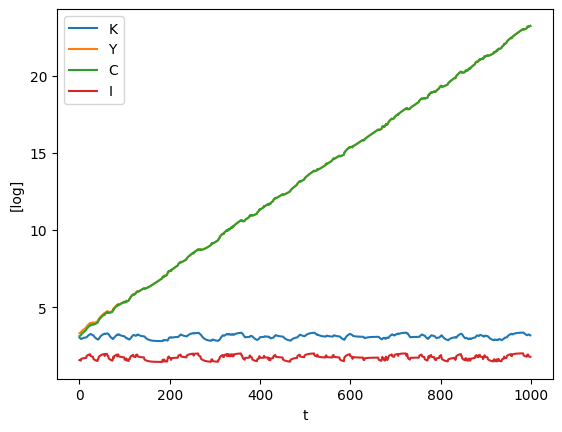

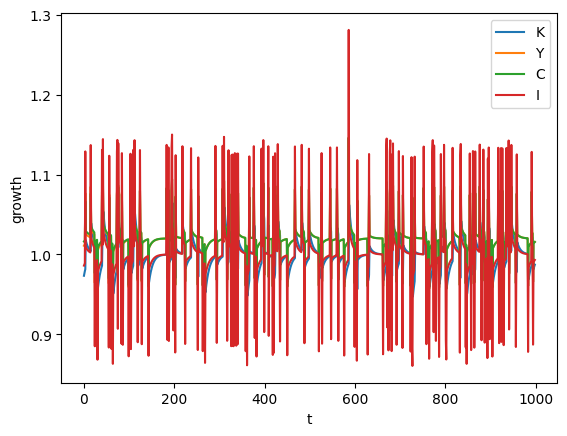

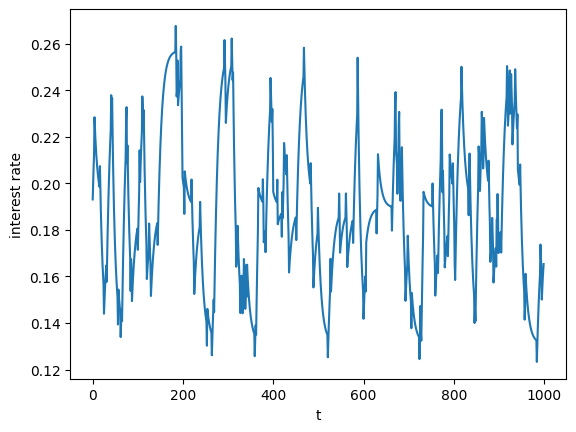

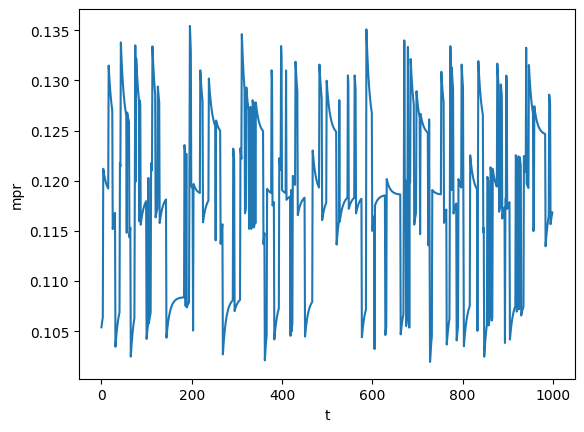

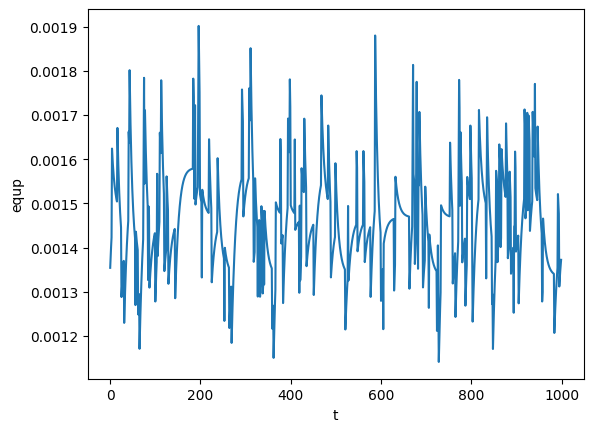

In [1468]:
analysis(sim_dict)

In [1469]:
pwd

'/content'